# 05 — Balanced Recurrent Network

**Goal of this notebook.** Every previous notebook studied a single neuron in isolation. Here we scale up to **1000 LIF neurons** — 80% excitatory, 20% inhibitory, sparsely and randomly connected, each independently driven by background Poisson input — and ask what happens at the *network* level.

The specific phenomenon we're after is the **Asynchronous-Irregular (AI) regime** (Brunel, 2000; van Vreeswijk & Sompolinsky, 1996): individual neurons fire *irregularly* (their own spike trains look almost Poisson), the population as a whole fires *asynchronously* (no shared rhythm), and the mean population rate is *low and stable* — even though every neuron is bombarded by strong, constantly-fluctuating synaptic input from hundreds of its neighbors. This is thought to be close to the regime cortical circuits actually operate in, and it is a genuinely emergent, network-level property: no single neuron in this simulation is doing anything an isolated LIF neuron under noisy current injection wouldn't also do (Notebook 01, Section 5) — it's the *combination*, at scale, with **Dale's law** and **inhibition scaled well above excitation**, that produces stability instead of runaway synchrony.

In [25]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from src.network_builder import BalancedNetwork, compute_population_rate, isi_cv

%matplotlib inline

mpl.rcParams.update({
    "figure.dpi": 105,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

COLOR_EXC = "#2b6cb0"
COLOR_INH = "#e53e3e"
COLOR_RATE = "#2d3748"


## 1. Build the network

1000 neurons, Dale's law enforced (the first 800 indices are excitatory, the last 200 inhibitory — `SparseConnectivity` never mixes a neuron's outgoing sign), 10% connection probability, and inhibitory synaptic weights scaled 5x above excitatory ones (`g=5`). Every neuron additionally receives its own independent Poisson background spike train, filtered through an exponential synapse — without this, a network with no external drive and only leaky, sparsely-connected neurons would simply never spike at all.

In [26]:
net = BalancedNetwork(n_neurons=1000, frac_exc=0.8, p_connect=0.1,
                       w_exc=2.0, g=5.0, bg_rate=1000.0, bg_weight=25.0,
                       dt=0.1, seed=42)

print(f"Network size:        {net.n_neurons}  ({net.n_exc} excitatory, {net.n_inh} inhibitory)")
print(f"Connection density:  {net.conn.density:.3f}  (target was {net.conn.p_connect})")
print(f"w_exc = {net.conn.w_exc} pA-equiv,  w_inh = {net.conn.w_inh} pA-equiv  (g = {net.conn.g})")

in_degree = np.asarray((net.conn.W != 0).sum(axis=1)).flatten()
in_degree_exc_source = np.asarray((net.conn.W[:, :net.n_exc] != 0).sum(axis=1)).flatten()
in_degree_inh_source = np.asarray((net.conn.W[:, net.n_exc:] != 0).sum(axis=1)).flatten()
print(f"Mean total in-degree: {in_degree.mean():.1f}  "
      f"(mean E-in: {in_degree_exc_source.mean():.1f}, mean I-in: {in_degree_inh_source.mean():.1f})")


Network size:        1000  (800 excitatory, 200 inhibitory)
Connection density:  0.100  (target was 0.1)
w_exc = 2.0 pA-equiv,  w_inh = -10.0 pA-equiv  (g = 5.0)
Mean total in-degree: 99.6  (mean E-in: 79.5, mean I-in: 20.1)


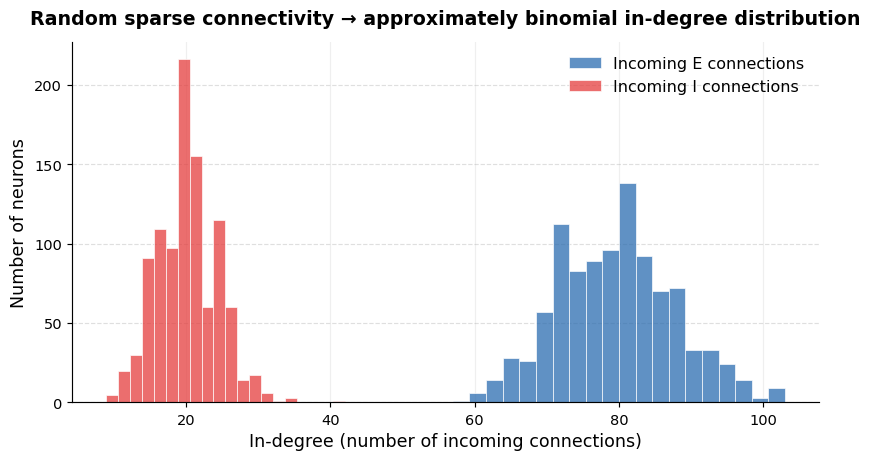

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(in_degree_exc_source, bins=20, alpha=0.75, color=COLOR_EXC,
        edgecolor="white", linewidth=0.6, label="Incoming E connections")
ax.hist(in_degree_inh_source, bins=20, alpha=0.75, color=COLOR_INH,
        edgecolor="white", linewidth=0.6, label="Incoming I connections")

ax.set_xlabel("In-degree (number of incoming connections)", fontsize=12)
ax.set_ylabel("Number of neurons", fontsize=12)
ax.set_title("Random sparse connectivity → approximately binomial in-degree distribution",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 2. Run the network and look at the raster

We simulate 1500 ms at dt=0.1ms (the project-standard Euler step for every network simulation) and record every spike, network-wide.

In [28]:
T = 1500.0
t0 = time.time()
out = net.simulate(T=T)
runtime = time.time() - t0
print(f"Simulated {T:.0f} ms ({int(T/net.dt)} steps, {net.n_neurons} neurons) in {runtime:.2f} s.")
print(f"Total spikes: {len(out['spike_times'])}")


Simulated 1500 ms (15000 steps, 1000 neurons) in 1.26 s.
Total spikes: 4759


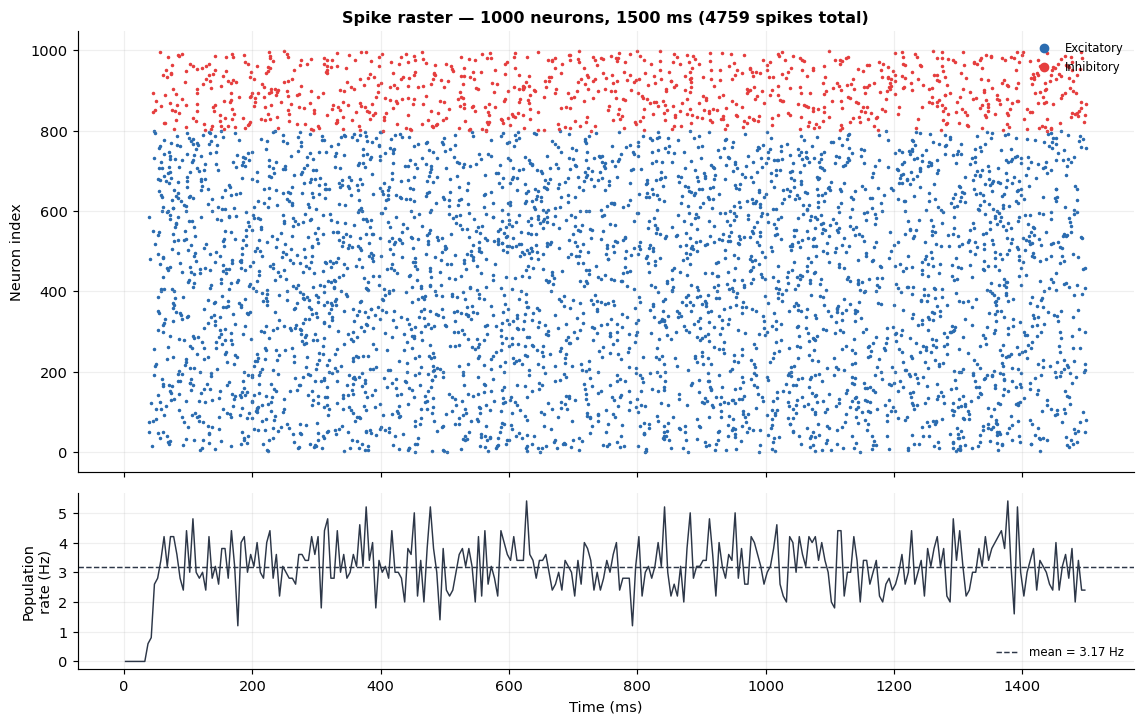

In [29]:
fig, (ax_raster, ax_rate) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                          gridspec_kw={"height_ratios": [2.5, 1]})

exc_mask = out["spike_neurons"] < net.n_exc
inh_mask = ~exc_mask
ax_raster.scatter(out["spike_times"][exc_mask], out["spike_neurons"][exc_mask],
                   s=2, color=COLOR_EXC, label="Excitatory", rasterized=True)
ax_raster.scatter(out["spike_times"][inh_mask], out["spike_neurons"][inh_mask],
                   s=2, color=COLOR_INH, label="Inhibitory", rasterized=True)
ax_raster.set_ylabel("Neuron index")
ax_raster.set_title(f"Spike raster — {net.n_neurons} neurons, {T:.0f} ms "
                     f"({len(out['spike_times'])} spikes total)")
ax_raster.legend(markerscale=4, loc="upper right", fontsize=8)

bin_centers, pop_rate = compute_population_rate(out["spike_times"], net.n_neurons, T, bin_size=5.0)
ax_rate.plot(bin_centers, pop_rate, color=COLOR_RATE, lw=1)
ax_rate.axhline(pop_rate.mean(), color=COLOR_RATE, ls="--", lw=1,
                 label=f"mean = {pop_rate.mean():.2f} Hz")
ax_rate.set_xlabel("Time (ms)"); ax_rate.set_ylabel("Population\nrate (Hz)")
ax_rate.legend(fontsize=8)

plt.tight_layout()
plt.show()


No visible stripes, no synchronized volleys, no silent-then-bursting alternation — spikes are scattered fairly uniformly across both neurons and time, and the 5ms-binned population rate fluctuates around a stable mean rather than oscillating or diverging. This is the qualitative signature of the AI regime.

## 3. What a single neuron's subthreshold voltage looks like

Zoom into two individual neurons — one excitatory, one inhibitory — and look at their raw membrane potential, not just their spikes. In the AI regime, a neuron's voltage should spend most of its time well below threshold, buffeted by a constant barrage of small synaptic fluctuations, only occasionally reaching threshold. This is the same *fluctuation-driven* spiking we first saw for a single LIF neuron under Poisson synaptic drive in Notebook 01 — just now it's the recurrent network itself providing that drive.

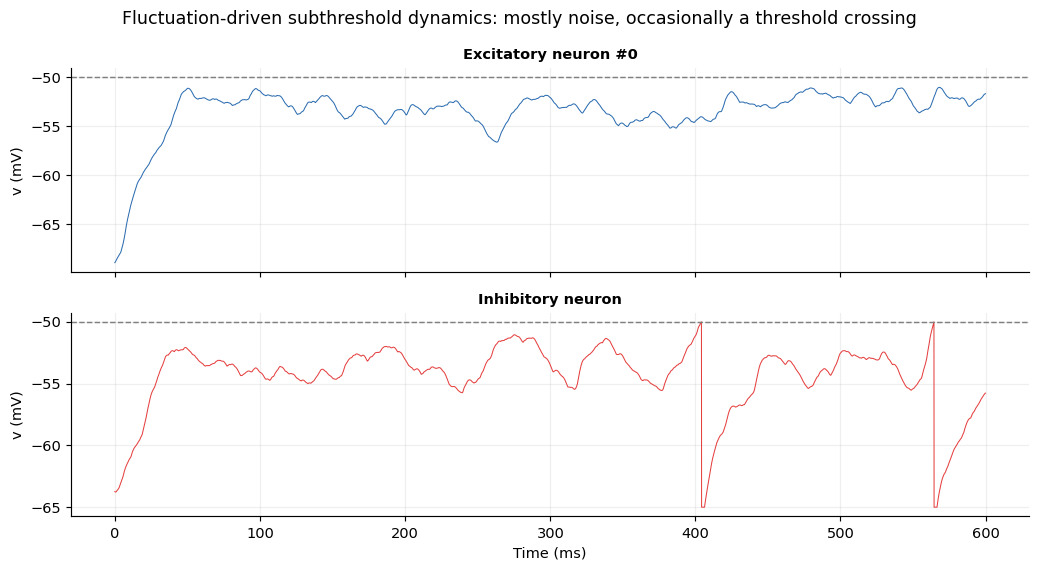

In [30]:
net2 = BalancedNetwork(n_neurons=1000, frac_exc=0.8, p_connect=0.1,
                        w_exc=2.0, g=5.0, bg_rate=1000.0, bg_weight=25.0, dt=0.1, seed=42)
out2 = net2.simulate(T=600.0, record_v_indices=[0, net2.n_exc])

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, idx, label, color in zip(axes, [0, net2.n_exc], ["Excitatory neuron #0", "Inhibitory neuron"],
                                  [COLOR_EXC, COLOR_INH]):
    ax.plot(out2["t"], out2["v_samples"][idx], color=color, lw=0.7)
    ax.axhline(net2.pop.v_th, color="gray", ls="--", lw=1)
    ax.set_ylabel("v (mV)")
    ax.set_title(label, fontsize=10)
axes[-1].set_xlabel("Time (ms)")
fig.suptitle("Fluctuation-driven subthreshold dynamics: mostly noise, occasionally a threshold crossing")
plt.tight_layout()
plt.show()


## 4. How irregular is "irregular"? ISI coefficient of variation

For each of a random sample of neurons with enough spikes to measure, compute the coefficient of variation (CV) of their inter-spike intervals. CV = 0 would mean perfectly clock-like firing; CV = 1 is the signature of a memoryless (Poisson) process; CV > 1 indicates burstiness.

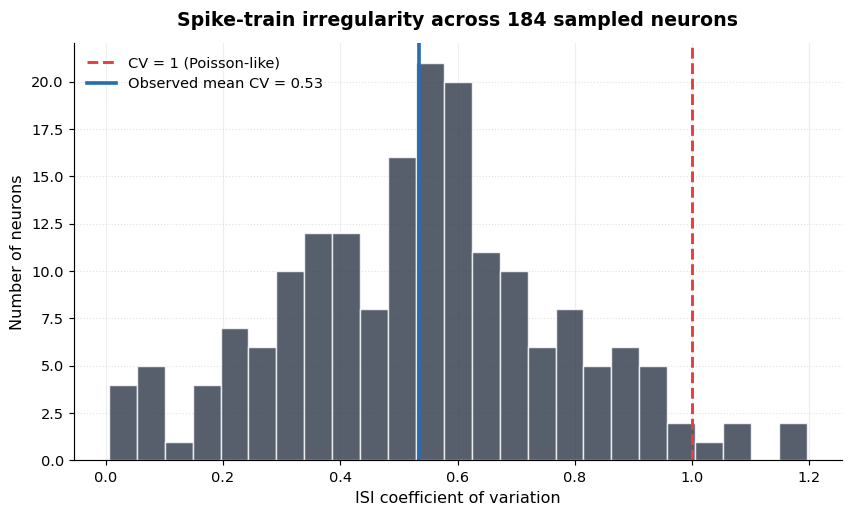

In [31]:
rng = np.random.default_rng(0)
sample_ids = rng.choice(net.n_neurons, size=200, replace=False)
cvs = []
for nid in sample_ids:
    st = out["spike_times"][out["spike_neurons"] == nid]
    c = isi_cv(st)
    if not np.isnan(c):
        cvs.append(c)
cvs = np.array(cvs)

fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

ax.hist(
    cvs,
    bins=25,
    color=COLOR_RATE,
    alpha=0.8,
    edgecolor="white",
    linewidth=1.0,
)

ax.axvline(
    1.0,
    color=COLOR_INH,
    linestyle="--",
    linewidth=2,
    label="CV = 1 (Poisson-like)",
)

ax.axvline(
    cvs.mean(),
    color=COLOR_EXC,
    linestyle="-",
    linewidth=2.5,
    label=f"Observed mean CV = {cvs.mean():.2f}",
)

ax.set_xlabel("ISI coefficient of variation", fontsize=11)
ax.set_ylabel("Number of neurons", fontsize=11)
ax.set_title(
    f"Spike-train irregularity across {len(cvs)} sampled neurons",
    fontsize=13,
    pad=12,
)

ax.grid(True, axis="y", linestyle=":", alpha=0.35)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis="both", labelsize=10)

plt.show()


A mean CV in the 0.4–0.6 range (well above the CV ~ 0 a clock-like or purely mean-driven LIF neuron would show — recall Notebook 01's F-I curve trials, which were essentially perfectly regular under constant current) confirms these spike trains are substantially irregular, driven by fluctuations rather than a fixed mean current. It is more regular than a strict CV=1 Poisson process — unsurprising, since the LIF refractory period and reset impose some structure a truly memoryless process wouldn't have — but this is a genuinely fluctuation-dominated, irregular firing regime, not a clock.

## 5. Excitatory vs. inhibitory firing rates

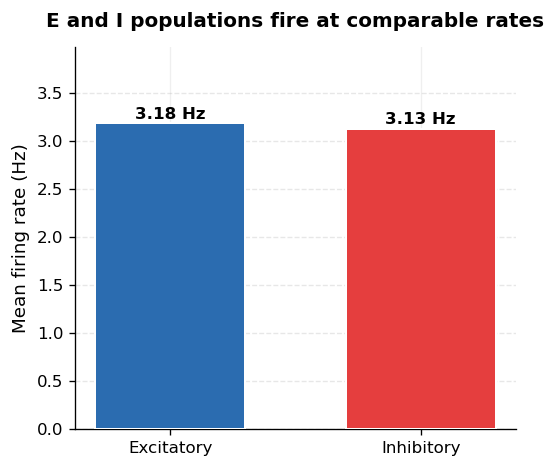

In [32]:
rate_exc = exc_mask.sum() / net.n_exc / (T / 1000.0)
rate_inh = inh_mask.sum() / net.n_inh / (T / 1000.0)

fig, ax = plt.subplots(figsize=(4.5, 4), dpi=120)
bars = ax.bar(
    ["Excitatory", "Inhibitory"],
    [rate_exc, rate_inh],
    color=[COLOR_EXC, COLOR_INH],
    edgecolor="white",
    linewidth=1.2,
    width=0.6,
    zorder=3,
)
ax.set_ylabel("Mean firing rate (Hz)", fontsize=11)
ax.set_title("E and I populations fire at comparable rates", fontsize=12, fontweight="bold", pad=12)

ax.grid(axis="y", alpha=0.3, linestyle="--", zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for b, r in zip(bars, [rate_exc, rate_inh]):
    ax.text(b.get_x() + b.get_width()/2, r + 0.05, f"{r:.2f} Hz", ha="center", fontsize=10, fontweight="bold")

ax.set_ylim(0, max(rate_exc, rate_inh) * 1.25)

fig.tight_layout()
plt.show()


## 6. Why strong inhibition matters: the balance mechanism directly

The defining claim of a "balanced network" is that recurrent inhibition *tracks* recurrent excitation closely enough to prevent runaway amplification, keeping the net current fluctuation-dominated instead of mean-dominated. We can demonstrate this directly: fix everything except the inhibitory scaling factor `g` (recall `w_inh = -g * w_exc`) and watch what happens to the population rate as we sweep it, at two different excitatory weight levels.

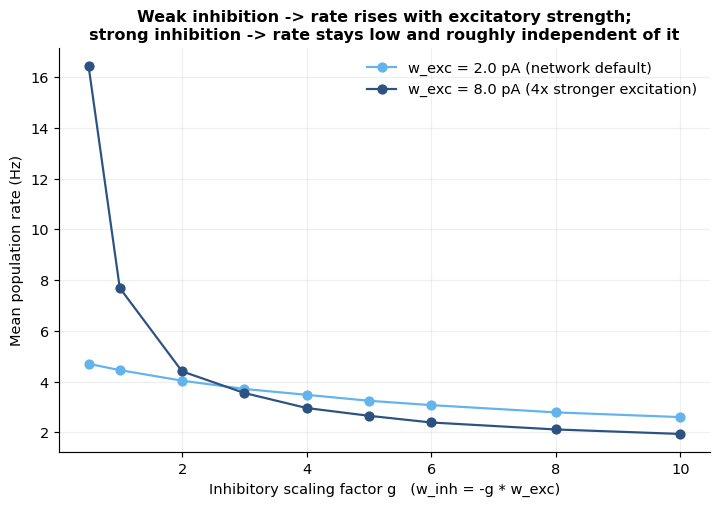

In [33]:
g_values = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0])

fig, ax = plt.subplots(figsize=(8, 5))
for w_exc, color, label in [(2.0, "#63b3ed", "w_exc = 2.0 pA (network default)"),
                             (8.0, "#2c5282", "w_exc = 8.0 pA (4x stronger excitation)")]:
    rates = []
    for g in g_values:
        net_g = BalancedNetwork(n_neurons=800, w_exc=w_exc, g=g,
                                 bg_rate=1000.0, bg_weight=25.0, seed=10)
        out_g = net_g.simulate(T=800.0)
        rates.append(len(out_g["spike_times"]) / net_g.n_neurons / 0.8)
    ax.plot(g_values, rates, "o-", color=color, label=label)

ax.set_xlabel("Inhibitory scaling factor g   (w_inh = -g * w_exc)")
ax.set_ylabel("Mean population rate (Hz)")
ax.set_title("Weak inhibition -> rate rises with excitatory strength;\nstrong inhibition -> rate stays low and roughly independent of it")
ax.legend()
plt.show()


With weak inhibition (small `g`), a 4x stronger excitatory weight produces a visibly higher population rate — recurrent excitation is amplifying itself largely unchecked. As `g` grows, both curves converge toward a low, stable rate: inhibition has become strong enough to track and cancel the extra excitatory drive almost regardless of exactly how strong that excitation is. That convergence — rate becoming insensitive to the *excitatory* weight once inhibition is strong enough to dominate — is the balanced network's namesake mechanism, not just a qualitative story.

## Summary — and the whole project, in one picture

- 1000 sparsely-connected LIF neurons, driven only by independent background noise and each other, self-organize into the **Asynchronous-Irregular regime**: scattered rasters, a stable population rate, and individually irregular (CV well above a clock-like 0, comparable to but somewhat below the memoryless-Poisson value of 1) spike trains.
- This is a genuinely emergent property of the **network**, not of any single neuron's nonlinearity — the neurons here are the *simplest* model in this whole project (plain LIF), no adaptation, no exponential nonlinearity.
- The mechanism is **balance**: Dale's law plus inhibitory weights scaled well above excitatory ones lets recurrent inhibition track and cancel recurrent excitation, which is what keeps the network in a low-rate, fluctuation-driven regime instead of runaway, mean-driven synchrony — demonstrated directly by the g-sweep above.

That closes the ladder this project set out to build:

$$\text{Passive} \;\to\; \text{LIF} \;\to\; \text{EIF (nonlinear)} \;\to\; \text{AdEx (+ adaptation)} \;\to\; \text{1000-neuron balanced network}$$

— from a single equation with no spikes at all, to a network whose *collective* behavior looks like a small piece of cortex.
